In [134]:
import pandas as pd

df = pd.read_csv("../../darkom-annonces.csv")

print("Nombre de lignes avant :", len(df))

doublons = df[df.duplicated(subset=["annonce_id"], keep=False)]
print("Nombre de lignes dupliquées :", len(doublons))

df = df.drop_duplicates(subset=["annonce_id"])

print("Nombre de lignes après suppression :", len(df))
print(doublons[["annonce_id"]].head(10))

Nombre de lignes avant : 1508
Nombre de lignes dupliquées : 16
Nombre de lignes après suppression : 1500
    annonce_id
127  ANO000263
294  ANO000868
320  ANO000824
364  ANO000679
461  ANO001471
577  ANO000248
585  ANO000824
599  ANO000679
894  ANO001471
977  ANO000868


In [135]:
# vérifier les valeurs manquantes
print(df[[
    "date_publication",
    "quartier",
    "nb_chambres",
    "nb_salles_bain",
    "etage",
    "annee_construction",
    "type_bien",
    "transaction"
]].isnull().sum())

date_publication       76
quartier              415
nb_chambres           129
nb_salles_bain        103
etage                 232
annee_construction    203
type_bien              38
transaction            38
dtype: int64


In [136]:
print(df[[
    "nb_chambres",
    "nb_salles_bain",
    "etage",
    "annee_construction"
]].skew())

nb_chambres           4.492335
nb_salles_bain        3.418612
etage                 1.202135
annee_construction   -0.881527
dtype: float64


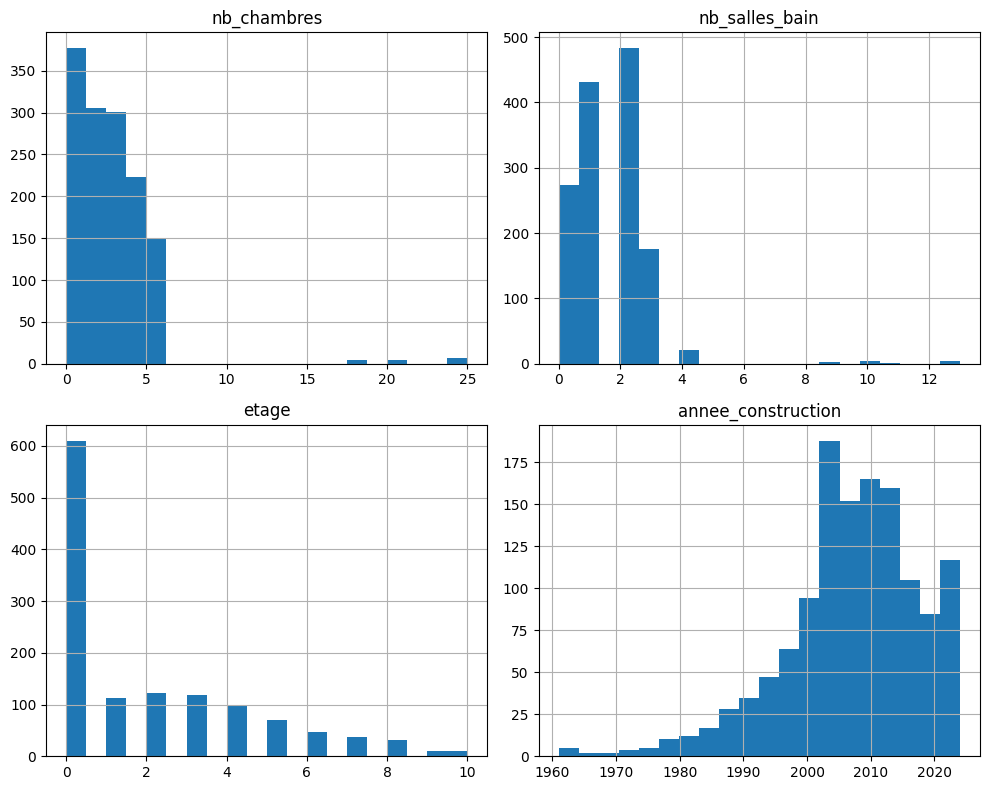

In [137]:
import matplotlib.pyplot as plt

df[["nb_chambres", "nb_salles_bain", "etage", "annee_construction"]].hist(
    figsize=(10, 8),
    bins=20
)
plt.tight_layout()
plt.show()

In [138]:
# imputation par la médiane pour les variables numériques
df["nb_chambres"] = df["nb_chambres"].fillna(df["nb_chambres"].median())
df["nb_salles_bain"] = df["nb_salles_bain"].fillna(df["nb_salles_bain"].median())
df["etage"] = df["etage"].fillna(df["etage"].median())
df["annee_construction"] = df["annee_construction"].fillna(df["annee_construction"].median())

print(df[[
    "nb_chambres",
    "nb_salles_bain",
    "etage",
    "annee_construction"
]].isnull().sum())

nb_chambres           0
nb_salles_bain        0
etage                 0
annee_construction    0
dtype: int64


In [139]:
# distribution des variables catégorielles
print("Distribution de quartier :")
print(df["quartier"].value_counts(dropna=False).head(10))

print("\nDistribution de type_bien :")
print(df["type_bien"].value_counts(dropna=False))

print("\nDistribution de transaction :")
print(df["transaction"].value_counts(dropna=False))

Distribution de quartier :
quartier
NaN               415
Centre            168
Ville Nouvelle     83
Medina             74
Hay Qods           58
M'diq              58
Hamria             51
Hay Mohammadi      48
Hay Essalam        45
Talborjt           44
Name: count, dtype: int64

Distribution de type_bien :
type_bien
Appartement    741
Villa          366
Terrain        147
Bureau         140
Duplex          68
NaN             38
Name: count, dtype: int64

Distribution de transaction :
transaction
Vente       1043
Location     419
NaN           38
Name: count, dtype: int64


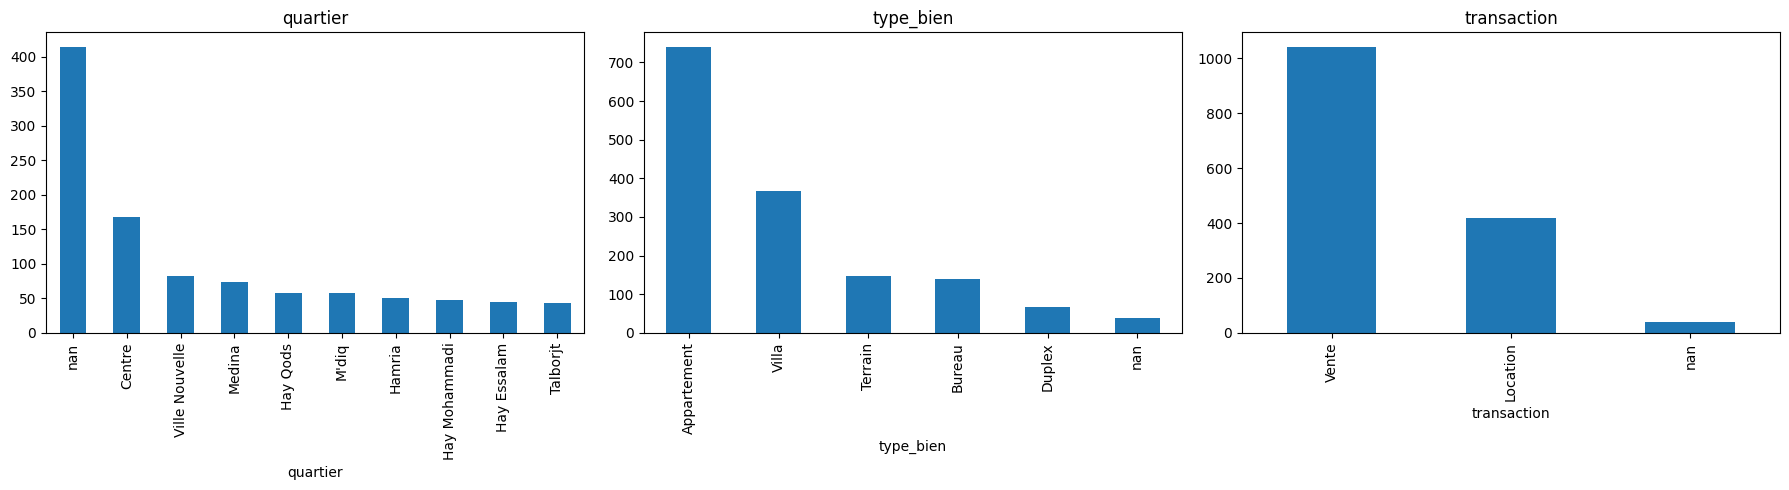

In [140]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["quartier"].value_counts(dropna=False).head(10).plot(kind="bar", ax=axes[0], title="quartier")
df["type_bien"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], title="type_bien")
df["transaction"].value_counts(dropna=False).plot(kind="bar", ax=axes[2], title="transaction")

plt.tight_layout()
plt.show()

In [141]:
# imputation de type_bien et transaction par le mode global
df["type_bien"] = df["type_bien"].fillna(df["type_bien"].mode()[0])
df["transaction"] = df["transaction"].fillna(df["transaction"].mode()[0])

# imputation de quartier par le mode de chaque ville
df["quartier"] = df.groupby("ville")["quartier"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

df["quartier"] = df["quartier"].fillna(df["quartier"].mode()[0])

print(df[["quartier", "type_bien", "transaction"]].isnull().sum())

quartier       0
type_bien      0
transaction    0
dtype: int64


In [142]:
print(df[["prix", "surface", "nb_chambres"]].skew())

prix           10.362369
surface         8.157085
nb_chambres     4.654275
dtype: float64


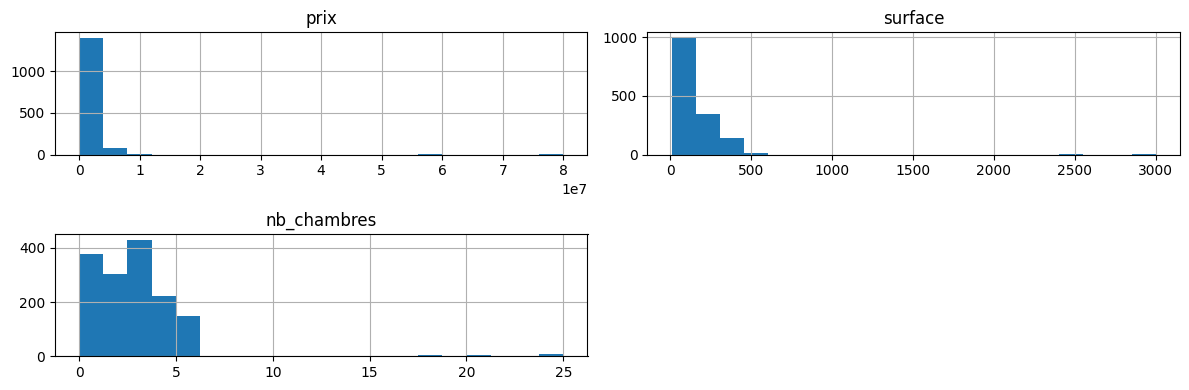

In [143]:
import matplotlib.pyplot as plt

df[["prix", "surface", "nb_chambres"]].hist(figsize=(12, 4), bins=20)
plt.tight_layout()
plt.show()

In [144]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    borne_min = Q1 - 1.5 * IQR
    borne_max = Q3 + 1.5 * IQR

    outliers = df[(df[column] < borne_min) | (df[column] > borne_max)]

    print(f"\nColonne : {column}")
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Borne min =", borne_min)
    print("Borne max =", borne_max)
    print("Nombre d'outliers =", len(outliers))

    return borne_min, borne_max, outliers

In [145]:
borne_min_prix, borne_max_prix, outliers_prix = detect_outliers_iqr(df, "prix")
borne_min_surface, borne_max_surface, outliers_surface = detect_outliers_iqr(df, "surface")
borne_min_ch, borne_max_ch, outliers_ch = detect_outliers_iqr(df, "nb_chambres")


Colonne : prix
Q1 = 11549.16
Q3 = 1821020.8499999999
IQR = 1809471.69
Borne min = -2702658.375
Borne max = 4535228.385
Nombre d'outliers = 101

Colonne : surface
Q1 = 79.8825
Q3 = 217.29999999999998
IQR = 137.4175
Borne min = -126.24374999999998
Borne max = 423.42625
Nombre d'outliers = 40

Colonne : nb_chambres
Q1 = 1.0
Q3 = 4.0
IQR = 3.0
Borne min = -3.5
Borne max = 8.5
Nombre d'outliers = 16


In [146]:
df.loc[(df["prix"] < borne_min_prix) | (df["prix"] > borne_max_prix), "prix"] = pd.NA
df.loc[(df["surface"] < borne_min_surface) | (df["surface"] > borne_max_surface), "surface"] = pd.NA
df.loc[(df["nb_chambres"] < borne_min_ch) | (df["nb_chambres"] > borne_max_ch), "nb_chambres"] = pd.NA

# imputation par la médiane
df["prix"] = df["prix"].fillna(df["prix"].median())
df["surface"] = df["surface"].fillna(df["surface"].median())
df["nb_chambres"] = df["nb_chambres"].fillna(df["nb_chambres"].median())

In [147]:
print(df[["prix", "surface", "nb_chambres"]].isnull().sum())

prix           0
surface        0
nb_chambres    0
dtype: int64


In [148]:
df.to_csv("../annonces_clean.csv", index=False, encoding="utf-8")

In [149]:
import os

df.to_csv("../annonces_clean.csv", index=False, encoding="utf-8")

print("exists:", os.path.exists("../annonces_clean.csv"))
print("absolute path:", os.path.abspath("../annonces_clean.csv"))

exists: True
absolute path: c:\Users\user\Desktop\darkom_dwh_project\scripts\annonces_clean.csv


In [150]:
print("Villes uniques :")
print(df["ville"].unique())

print("\nTypes de bien uniques :")
print(df["type_bien"].unique())

print("\nTransactions uniques :")
print(df["transaction"].unique())

Villes uniques :
<StringArray>
[    'Meknès',    'Kenitra',      'Oujda',     'Tanger',      'Rabat',
     'Agadir',     'TANGER',        'Fès',     'MEKNÈS',      'oujda',
 'Casablanca',    'tétouan',  'MARRAKECH',  'Marrakech',        'fès',
    'Tétouan',    'TÉTOUAN',      'RABAT', 'CASABLANCA',    'KENITRA',
        'FÈS',       'Casa',      'OUJDA',     'tanger',      'rabat',
     'agadir',     'meknès',  'marrakech',    'kenitra',     'AGADIR',
 'casablanca']
Length: 31, dtype: str

Types de bien uniques :
<StringArray>
['Terrain', 'Appartement', 'Villa', 'Bureau', 'Duplex']
Length: 5, dtype: str

Transactions uniques :
<StringArray>
['Vente', 'Location']
Length: 2, dtype: str


In [151]:
df["ville"] = df["ville"].str.strip().str.title()
df["ville"] = df["ville"].replace({"Casa": "Casablanca"})

In [152]:
df["type_bien"] = df["type_bien"].str.strip().str.title()

In [153]:
df["transaction"] = df["transaction"].str.strip().str.title()

In [154]:
print("Villes après standardisation :")
print(df["ville"].unique())

print("\nTypes de bien après standardisation :")
print(df["type_bien"].unique())

print("\nTransactions après standardisation :")
print(df["transaction"].unique())

Villes après standardisation :
<StringArray>
[    'Meknès',    'Kenitra',      'Oujda',     'Tanger',      'Rabat',
     'Agadir',        'Fès', 'Casablanca',    'Tétouan',  'Marrakech']
Length: 10, dtype: str

Types de bien après standardisation :
<StringArray>
['Terrain', 'Appartement', 'Villa', 'Bureau', 'Duplex']
Length: 5, dtype: str

Transactions après standardisation :
<StringArray>
['Vente', 'Location']
Length: 2, dtype: str


In [155]:
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce")
df["date_publication"] = df["date_publication"].dt.date

df["prix"] = pd.to_numeric(df["prix"], errors="coerce")
df["surface"] = pd.to_numeric(df["surface"], errors="coerce")
df["nb_chambres"] = pd.to_numeric(df["nb_chambres"], errors="coerce")
df["nb_salles_bain"] = pd.to_numeric(df["nb_salles_bain"], errors="coerce")
df["etage"] = pd.to_numeric(df["etage"], errors="coerce")
df["annee_construction"] = pd.to_numeric(df["annee_construction"], errors="coerce")

In [156]:
df["date_publication"].unique

<bound method Series.unique of 0       2023-05-05
1       2023-08-20
2       2023-06-20
3       2024-01-21
4       2024-03-19
           ...    
1503    2024-10-22
1504    2024-01-05
1505    2023-08-30
1506    2024-06-05
1507    2024-02-23
Name: date_publication, Length: 1500, dtype: object>

In [157]:
print(df.dtypes)

annonce_id                str
date_publication       object
titre                     str
ville                     str
quartier                  str
type_bien                 str
transaction               str
prix                  float64
surface               float64
nb_chambres           float64
nb_salles_bain        float64
etage                 float64
annee_construction    float64
dtype: object


In [158]:
from datetime import datetime
import pandas as pd

# prix par m²
df["prix_m2"] = df["prix"] / df["surface"].replace(0, pd.NA)

# âge estimé du bien
current_year = datetime.now().year
df["age_bien"] = current_year - df["annee_construction"]

# catégories de prix
def categoriser_prix(prix):
    if prix < 300000:
        return "Economique"
    elif prix < 700000:
        return "Moyen"
    elif prix < 1500000:
        return "Haut standing"
    else:
        return "Luxe"

df["categorie_prix"] = df["prix"].apply(categoriser_prix)

# catégories de surface
def categoriser_surface(surface):
    if surface < 80:
        return "Petit"
    elif surface <= 150:
        return "Moyen"
    else:
        return "Grand"

df["categorie_surface"] = df["surface"].apply(categoriser_surface)

# dimensions temporelles
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce")
df["annee_publication"] = df["date_publication"].dt.year
df["mois_publication"] = df["date_publication"].dt.month
df["trimestre_publication"] = df["date_publication"].dt.quarter

print(df[[
    "prix",
    "surface",
    "prix_m2",
    "annee_construction",
    "age_bien",
    "categorie_prix",
    "categorie_surface",
    "date_publication",
    "annee_publication",
    "mois_publication",
    "trimestre_publication"
]].head())

        prix  surface      prix_m2  annee_construction  age_bien  \
0  811401.04   314.40  2580.792112              2014.0      12.0   
1    3843.55    36.46   105.418267              2008.0      18.0   
2    9190.70    95.54    96.197404              2012.0      14.0   
3   30000.00    93.35   321.371184              2008.0      18.0   
4   20844.72   264.22    78.891530              2006.0      20.0   

  categorie_prix categorie_surface date_publication  annee_publication  \
0  Haut standing             Grand       2023-05-05             2023.0   
1     Economique             Petit       2023-08-20             2023.0   
2     Economique             Moyen       2023-06-20             2023.0   
3     Economique             Moyen       2024-01-21             2024.0   
4     Economique             Grand       2024-03-19             2024.0   

   mois_publication  trimestre_publication  
0               5.0                    2.0  
1               8.0                    3.0  
2          

In [159]:
df.to_csv("../annonces_clean.csv", index=False, encoding="utf-8")
print("Nouveau fichier clean exporté avec succès")

Nouveau fichier clean exporté avec succès


In [160]:
import pandas as pd
import psycopg2
import logging
import os
import traceback
from sqlalchemy import create_engine, text

# Création du dossier logs
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename="logs/clean.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Paramètres PostgreSQL
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("POSTGRES_DB", "darkom_dwh")
DB_USER = os.getenv("POSTGRES_USER", "postgres")
DB_PASS = os.getenv("POSTGRES_PASSWORD", "assia123")
DB_PORT = os.getenv("DB_PORT", "5432")

try:
    # Création de l'engine
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

    # Test de connexion
    with engine.connect() as conn:
        print("Connexion PostgreSQL OK")

        result = conn.execute(text("SELECT current_database();"))
        print("Base de données :", result.fetchone()[0])

        schema_check = conn.execute(text("""
            SELECT schema_name
            FROM information_schema.schemata
            WHERE schema_name = 'clean'
        """))

        if schema_check.fetchone() is None:
            raise Exception("Le schéma 'clean' n'existe pas dans la base de données.")

    # Insertion des données dans la table
    df.to_sql("annonces_clean", engine, schema="clean", if_exists="append", index=False)
    print("Insertion réussie dans annonces_clean")

except Exception as e:
    print("Erreur :", e)
    logging.error("Erreur : %s\n%s", e, traceback.format_exc())



Connexion PostgreSQL OK
Base de données : darkom_dwh
Insertion réussie dans annonces_clean
